In [4]:
%matplotlib inline
#import skmob
import pandas as pd
#import skmob.measures.individual as ind_measure
import torch
import gpytorch
from gpytorch.kernels import RQKernel as RQ, RBFKernel as SE, \
PeriodicKernel as PER, ScaleKernel, LinearKernel as LIN, MaternKernel as MAT, \
SpectralMixtureKernel as SMK, PiecewisePolynomialKernel as PPK, CylindricalKernel as CYL
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error
from gpytorch.constraints import Interval
import time

# Import intra-package scripts
import utils.helper_func as helper_func
import utils.GP as GP
import mobileDataToolkit.analysis as analysis
import mobileDataToolkit.preprocessing as preprocessing

In [5]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# Reading Data

In [23]:
file_path = "C:\\Users\\ekino\\OneDrive - UW\\GPR\\Data\\all_obs_preprocessed.csv"

d1 = preprocessing.dp_MultiTrip(file_path, 8765765)
d1.chooseUser(d1.data.user_ID.unique()[9])

## Preprocessing Data: Adding "DateTime" column, subsetting by a timeframe

In [8]:
d1.add_DateTime()

d1.subsetByTime('01/18/2020 00:00', '02/09/2020 00:00')

data = d1.Multi_Trip_Preprocess()

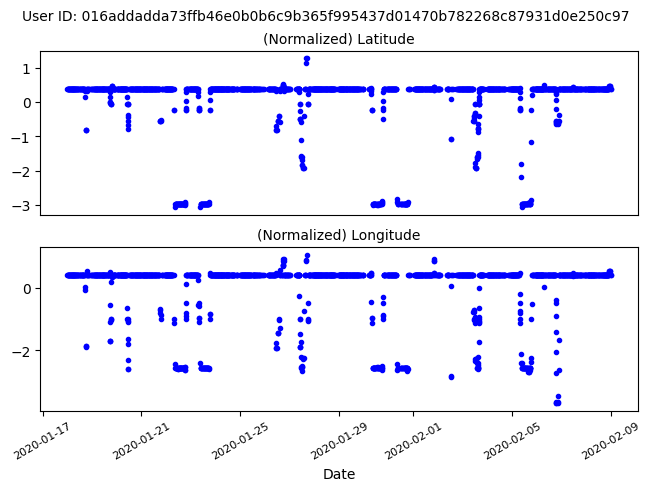

In [9]:
d1.mobVisualize(data)

In [9]:
d1.Multi_Trip_TrainTestSplit('2020-02-05 00:00', '2020-02-06 00:00')

In [ ]:
data[(data['Date_Time'] >= '2020-02-05 00:00') & (data['Date_Time'] < '2020-02-06 00:00')]

,level_0,index,unix_start_t,user_ID,mark_1,orig_lat,orig_long,orig_unc,human_start_t,Date_Time,...,day_4,day_5,day_6,week_1,week_2,week_3,week_4,week_5,month_1,month_2
1521,1521,122996,1580861134,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,16,2.002050e+11,2020-02-05 00:05:34,...,0,0,0,1,0,0,0,0,0,1
1522,1522,122997,1580861759,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,16,2.002050e+11,2020-02-05 00:15:59,...,0,0,0,1,0,0,0,0,0,1
1523,1523,122998,1580862359,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,16,2.002050e+11,2020-02-05 00:25:59,...,0,0,0,1,0,0,0,0,0,1
1524,1524,122999,1580862960,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,17,2.002050e+11,2020-02-05 00:36:00,...,0,0,0,1,0,0,0,0,0,1
1525,1525,123000,1580863563,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,17,2.002050e+11,2020-02-05 00:46:03,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1614,1614,123089,1580944248,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,17,2.002060e+11,2020-02-05 23:10:48,...,0,0,0,1,0,0,0,0,0,1
1615,1615,123090,1580944880,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,16,2.002060e+11,2020-02-05 23:21:20,...,0,0,0,1,0,0,0,0,0,1
1616,1616,123091,1580945508,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,17,2.002060e+11,2020-02-05 23:31:48,...,0,0,0,1,0,0,0,0,0,1
1617,1617,123092,1580946108,016addadda73ffb46e0b0b6c9b365f995437d01470b782...,1,47.903023,-122.225647,17,2.002060e+11,2020-02-05 23:41:48,...,0,0,0,1,0,0,0,0,0,1


In [105]:
import forest.jasmine.data2mobmat as data2mobmat
import forest.jasmine.mobmat2traj as mobmat2traj
import forest.jasmine.sogp_gps as sogp_gps
import sys

In [37]:
file_path = "C:\\Users\\ekino\\OneDrive - UW\\GPR\\Data\\all_obs_preprocessed.csv"

d1 = preprocessing.dp_MultiTrip(file_path, 8765765)
d1.chooseUser(d1.data.user_ID.unique()[9])
d1.add_DateTime()
d1.subsetByTime('01/18/2020 00:00', '02/09/2020 00:00')

test1 = d1.data[['unix_start_t','Date_Time','orig_lat','orig_long','orig_unc']]
test1['altitude'] = np.zeros(len(test1))
test1 = test1.iloc[:,[0,1,2,3,5,4]]
test1.columns = ['timestamp', 'UTC time', 'latitude', 'longitude', 'altitude', 'accuracy']
test1

,timestamp,UTC time,latitude,longitude,altitude,accuracy
0,1579306217,2020-01-18 00:10:17,47.903023,-122.225647,0.0,22
1,1579306861,2020-01-18 00:21:01,47.903023,-122.225647,0.0,17
2,1579308117,2020-01-18 00:41:57,47.903023,-122.225647,0.0,17
3,1579308751,2020-01-18 00:52:31,47.903023,-122.225647,0.0,17
4,1579309541,2020-01-18 01:05:41,47.903023,-122.225647,0.0,17
...,...,...,...,...,...,...
1895,1581199687,2020-02-08 22:08:07,47.909791,-122.221165,0.0,17
1896,1581203494,2020-02-08 23:11:34,47.909793,-122.221212,0.0,25
1897,1581204451,2020-02-08 23:27:31,47.909919,-122.221378,0.0,78
1898,1581204641,2020-02-08 23:30:41,47.903023,-122.225647,0.0,17


In [97]:
itrvl = 5
accuracy_lim = 500
r = 0.2
w = 0.3
h = 0.5

step1 = data2mobmat.GPS2MobMat(test1, itrvl, accuracy_lim, r, w, h)

Collapse data within 5 second intervals ...
Extract flights and pauses ...


In [100]:
step2 = data2mobmat.InferMobMat(step1, itrvl, accuracy_lim)

Infer unclassified windows ...
Merge consecutive pauses and bridge gaps ...


In [102]:
hi = pd.DataFrame(step2)
hi.columns = ['status', 'lat_start', 'lon_start', 'time_start', 'lat_end', 'lon_end', 'time_end', 'obs_indicator']
hi

,status,lat_start,lon_start,time_start,lat_end,lon_end,time_end,obs_indicator
0,2.0,47.903023,-122.225647,1579308.717,47.903023,-122.225647,1579363.717,1.0
1,1.0,47.903023,-122.225647,1579363.717,47.903023,-122.225647,1579378.717,1.0
2,2.0,47.903023,-122.225647,1579378.717,47.903023,-122.225647,1579448.717,1.0
3,1.0,47.903023,-122.225647,1579448.717,47.903023,-122.225647,1579468.717,1.0
4,2.0,47.903023,-122.225647,1579468.717,47.903023,-122.225647,1579508.717,1.0
...,...,...,...,...,...,...,...,...
59,1.0,47.903023,-122.225647,1581008.717,47.903023,-122.225647,1581028.717,1.0
60,2.0,47.903023,-122.225647,1581028.717,47.903023,-122.225647,1581068.717,1.0
61,1.0,47.903023,-122.225647,1581068.717,47.903023,-122.225647,1581078.717,1.0
62,2.0,47.903023,-122.225647,1581078.717,47.903023,-122.225647,1581193.717,1.0


In [126]:
test1.to_csv("Data/test/test.csv")

In [113]:
import forest.jasmine.traj2stats as traj2stats

In [209]:
study_folder = "Data/test"
output_dir = "Data/test_out"
tz_str = "America/Tijuana"
option = "daily"
save_traj = True 

parameters = traj2stats.Hyperparameters()

parameters

Hyperparameters(l1=864000, l2=2592000, l3=0.002, g=200, a1=5, a2=1, b1=0.3, b2=0.2, b3=0.5, d=100, sigma2=0.01, tol=0.05, switch=3, num=10, linearity=2, method='GLC', itrvl=10, accuracylim=51, r=None, w=None, h=None)

In [206]:
pars0 = [
    parameters.l1, parameters.l2, parameters.l3, parameters.a1,
    parameters.a2, parameters.b1, parameters.b2, parameters.b3
]
pars1 = [
    parameters.l1, parameters.l2, parameters.a1, parameters.a2,
    parameters.b1, parameters.b2, parameters.b3, parameters.g
]

orig_r = parameters.r
orig_w = parameters.w
orig_h = parameters.h

if orig_r is None:
    parameters.r = parameters.itrvl
if orig_h is None:
    parameters.h = parameters.r
if orig_w is None:
    parameters.w = np.mean(data.accuracy)

In [180]:
# process data
mobmat1 = data2mobmat.GPS2MobMat(
    test1, parameters.itrvl, parameters.accuracylim,
    parameters.r, parameters.w, parameters.h
)

Collapse data within 10 second intervals ...
Extract flights and pauses ...


In [184]:
mobmat2 = data2mobmat.InferMobMat(mobmat1, parameters.itrvl, parameters.r)

Infer unclassified windows ...
Merge consecutive pauses and bridge gaps ...


In [189]:
participant_id = '123423'
all_memory_dict = {}
all_memory_dict[str(participant_id)] = None

all_bv_set = {}
all_bv_set[str(participant_id)] = None

out_dict = sogp_gps.BV_select(
                mobmat2,
                parameters.sigma2,
                parameters.tol,
                parameters.d,
                pars0,
                all_memory_dict[str(participant_id)],
                all_bv_set[str(participant_id)],
            )

Selecting basis vectors ...


In [204]:
parameters.linearity

2

In [196]:
imp_table = mobmat2traj.ImputeGPS(
                    mobmat2, out_dict['BV_set'], parameters.method,
                    parameters.switch, parameters.num,
                    parameters.linearity, tz_str, pars1
)

Imputing missing trajectories ...


In [205]:
imp_table

array([], shape=(0, 7), dtype=float64)

In [198]:
traj = mobmat2traj.Imp2traj(imp_table, mobmat2, parameters.itrvl,
                            parameters.r, parameters.w, parameters.h)

Tidying up the trajectories...
